# Improving Recommendation By Improving the Quality of Image Embeddings



### Setting up useful variables

In [31]:
import os
## The base dir of the project
PROJECT_DIR = "/home/projects/IBRS/Image-Based-Recommendation-System"

## The "etc" dir contains all the files not tracked in GitHub
ETC_DIR = os.path.join(PROJECT_DIR, "etc")

## The .zip of the dataset is provided in the repository, but it's unzipped in "etc".
DATASET_ZIP_FILE = os.path.join(PROJECT_DIR, "dataset.zip")
DATASET_DIR = os.path.join(ETC_DIR, "dataset")
DATASET_METADATA_TXT_FILE = os.path.join(DATASET_DIR, "metadata.txt")
DATASET_METADATA_JSON_FILE = os.path.join(DATASET_DIR, "metadata.json")
DATASET_METADATA_DIR = os.path.join(DATASET_DIR, "metadata")

## SRC DIR
SRC_DIR = os.path.join(PROJECT_DIR, "src")

### Unzip the dataset

In [2]:
from src.utils import unzip_dataset
unzip_dataset(dataset_zip_file=DATASET_ZIP_FILE, dataset_dir=DATASET_DIR, etc_dir=ETC_DIR)

[INFO] Dataset already unzipped


In [5]:
from elasticsearch import Elasticsearch

es = Elasticsearch("http://localhost:9200")

index_name = "items"

if not es.indices.exists(index=index_name):
    es.indices.create(index=index_name, body=mapping)
    print("[INFO] Mapping create.")

In [6]:
metadata[0]

{'ID': 7541,
 'title': 'Christina Gavioli',
 'slug': 'christina-gavioli-3',
 'category': ['Fashion Women', 'Women Blouse and Dress'],
 'imPath': 'images/Fashion Women/Women Blouse and Dress/CHRISTINA_GAVIOLI.jpg'}

### Indexing the data in Elasticsearch

In [7]:
from elasticsearch.helpers import bulk

actions = [
    {
        "_index": index_name,
        "_id": item["ID"],
        "_source": item
    }
    for item in metadata
]

bulk(es, actions)
print("[INFO] Document indexed successfully")

[INFO] Document indexed successfully


## Extract Embeddings Using ResNet50

## Embedding Extraction with VLM Models (SigLIP & Vertex AI)

Defining an abstract base class for embedding extraction, and concrete implementations for SigLIP and Vertex AI.

In [ ]:
class ResNet50EmbeddingExtractor(ImageEmbeddingExtractor):
    def __init__():
        base_model = resnet50.ResNet50(weights='imagenet')
        model = Model(inputs=base_model.inputs, outputs=base_model.get_layer('avg_pool').output)

    def extract_embeddings(self, image_paths: List[str]):
        images = [load_image(path) for path in image_paths]
        batch = np.stack(images, axis=0)
        return self.model.predict(batch, verbose=0)

In [1]:
from abc import ABC, abstractmethod
from typing import List
import numpy as np
from PIL import Image
import torch
from transformers import AutoProcessor, AutoModel
from vertexai.vision_models import MultiModalEmbeddingModel, Image as VertexImage


class ImageEmbeddingExtractor(ABC):
    @abstractmethod
    def extract_embeddings(self, image_paths: List[str]) -> np.ndarray:
        """Extract embeddings for a batch of image paths."""
        pass


class SigLIPEmbeddingExtractor(ImageEmbeddingExtractor):
    def __init__(self, model_name="google/siglip-base-patch16-224"):
        self.processor = AutoProcessor.from_pretrained(model_name)
        self.model = AutoModel.from_pretrained(model_name)
        self.model.eval()

    def extract_embeddings(self, image_paths: List[str]) -> np.ndarray:
        images = [Image.open(path).convert("RGB") for path in image_paths]
        inputs = self.processor(images=images, return_tensors="pt")
        with torch.no_grad():
            embeddings = self.model.get_image_features(**inputs)
            embeddings = embeddings.pooler_output
        return embeddings.detach().cpu().numpy()

class VertexAIEmbeddingExtractor(ImageEmbeddingExtractor):
    def __init__(self, model_name="multimodalembedding"):
        self.model = MultiModalEmbeddingModel.from_pretrained(model_name)

    def extract_embeddings(self, image_paths: List[str]) -> np.ndarray:
        embeddings = []
        for path in image_paths:
            vertex_image = VertexImage.load_from_file(path)
            emb = self.model.get_embeddings(image=vertex_image)
            embeddings.append(emb.image_embedding)
        return np.array(embeddings)


/home/projects/IBRS/Image-Based-Recommendation-System/03 - Image Embeddings with VLM based models/etc/venv-03/lib/python3.12/site-packages/google/cloud/aiplatform/models.py:52: FutureWarning: Support for google-cloud-storage < 3.0.0 will be removed in a future version of google-cloud-aiplatform. Please upgrade to google-cloud-storage >= 3.0.0.
  from google.cloud.aiplatform.utils import gcs_utils


In [2]:
def extract_all_embeddings(extractor: ImageEmbeddingExtractor, image_paths: List[str]) -> np.ndarray:
    """
    Helper function that uses the provided extractor to get embeddings for a list of image paths.
    """
    return extractor.extract_embeddings(image_paths)

# Example usage:
# siglip_extractor = SigLIPEmbeddingExtractor()
# vertex_extractor = VertexAIEmbeddingExtractor()
# siglip_embeddings = extract_all_embeddings(siglip_extractor, img_paths)
# vertex_embeddings = extract_all_embeddings(vertex_extractor, img_paths)


In [29]:
from src.elastic import bulk_update_embeddings
import os

MODEL_FIELD_MAPPING = {
    "resnet": "image_features",
    "siglip": "siglip_features",
    "vertex_api": "vertexai_features"
}

def extract_embeddings_and_update_es(es, embedding_extractor: ImageEmbeddingExtractor, model: str = "resnet", index_name: str = "items", batch_size=128):
    # query ES to get all the image path
    query = {
        "size": batch_size,
        "query": {
            "bool": {
                "must_not": {
                    "exists": {"field": MODEL_FIELD_MAPPING.get(model)}
                }
            }
        }
    }
    
    response = es.search(index=index_name, body=query, scroll="5m")
    scroll_id = response["_scroll_id"]
    
    while True:
        items = response["hits"]["hits"]
    
        if not items:
            break
    
        # batch processing
        paths = [os.path.join(DATASET_DIR, item["_source"]["imPath"]) for item in items]
        embeddings = embedding_extractor.extract_embeddings(paths)
        bulk_update_embeddings(es, index_name, items, embeddings, model)
    
        # continue scrolling
        response = es.scroll(scroll_id=scroll_id, scroll="5m")
    
    print("DONE: all embeddings updated.")

In [3]:
from elasticsearch import Elasticsearch

es = Elasticsearch("http://localhost:9200")

siglip_extractor = SigLIPEmbeddingExtractor()

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

In [13]:
paths = ["/home/projects/IBRS/Image-Based-Recommendation-System/etc/dataset/img1.jpg"]

embeddings = siglip_extractor.extract_embeddings(paths)

In [14]:
embeddings = embeddings
np.shape(embeddings)

(1, 768)

### Update the ES mapping
doc: https://elasticsearch-py.readthedocs.io/en/v9.1.3/api/indices.html#elasticsearch.client.IndicesClient.put_mapping

```json
"image_features": {
    "type": "dense_vector",
    "dims": 2048,
    "index": true,
    "similarity": "cosine"
}
```

In [19]:
def update_index_mapping(es, index_name, query):
    """
    Updates the index mapping to add new fields if they don't exist.

    :param es: Elasticsearch client instance
    :param index_name: Name of the index
    :param query: Mapping definition (body for put_mapping)
    """
    es.indices.put_mapping(index=index_name, body=query)
    print(f"[INFO] Index '{index_name}' mapping updated.")

siglip_field = MODEL_FIELD_MAPPING.get("siglip")

In [21]:
mapping = {
    "properties": {
        siglip_field: { 
            "type": "dense_vector",
            "dims": 768,
            "index": True,
            "similarity": "cosine"
        }
    }
}

update_index_mapping(es, index_name="items", query=mapping)

[INFO] Index 'items' mapping updated.


In [24]:
# check that the mapping has been updated
es.indices.get_mapping(index="items")

ObjectApiResponse({'items': {'mappings': {'properties': {'ID': {'type': 'integer'}, 'category': {'type': 'keyword'}, 'imPath': {'type': 'keyword'}, 'image_features': {'type': 'dense_vector', 'dims': 2048, 'index': True, 'similarity': 'cosine', 'index_options': {'type': 'bbq_hnsw', 'm': 16, 'ef_construction': 100, 'rescore_vector': {'oversample': 3.0}}}, 'siglip_features': {'type': 'dense_vector', 'dims': 768, 'index': True, 'similarity': 'cosine', 'index_options': {'type': 'bbq_hnsw', 'm': 16, 'ef_construction': 100, 'rescore_vector': {'oversample': 3.0}}}, 'slug': {'type': 'text', 'fields': {'keyword': {'type': 'keyword'}}}, 'title': {'type': 'text', 'fields': {'keyword': {'type': 'keyword'}}}}}}})

In [32]:
# siglip features to existing documents

extract_embeddings_and_update_es(
    es=es, 
    embedding_extractor=siglip_extractor, 
    model="siglip"
)

[INFO] Updated 128 documents with siglip embeddings.
[INFO] Updated 128 documents with siglip embeddings.
[INFO] Updated 128 documents with siglip embeddings.
[INFO] Updated 128 documents with siglip embeddings.
[INFO] Updated 128 documents with siglip embeddings.
[INFO] Updated 128 documents with siglip embeddings.
[INFO] Updated 128 documents with siglip embeddings.
[INFO] Updated 128 documents with siglip embeddings.
[INFO] Updated 128 documents with siglip embeddings.
[INFO] Updated 128 documents with siglip embeddings.
[INFO] Updated 128 documents with siglip embeddings.
[INFO] Updated 128 documents with siglip embeddings.
[INFO] Updated 119 documents with siglip embeddings.
DONE: all embeddings updated.


## Perform Recommendations

* knn search with filter ref: https://www.elastic.co/docs/solutions/search/vector/knn#knn-search-filter-example

In [12]:
item_ids = [item['ID'] for item in metadata]

def knn_search(item_id, k=10, num_candidates=100, apply_filter=False):
    # Query Elasticsearch to get all the fields of the referenced item 
    res = es.get(index=index_name, id=item_id)
    ref_item = res['_source']

    # build the knn query. Add a filter on the category if apply_filter is enabled
    knn_query = {
        "knn": {
            "field": "image_features",
            "query_vector": ref_item['image_features'],
            "k": k,
            "num_candidates": num_candidates
        }
    }

    
    if apply_filter:
        knn_query["knn"]["filter"] = {
            "term": {
                "category": ref_item['category'][0]
            }
        }
        
    # execute the knn query
    res = es.search(index=index_name, query=knn_query)
    knn_items = res['hits']['hits']
    return ref_item, knn_items

### Display Recommendations

In [13]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

def display_knn(knn_items, ref_item=None, src_img_path=None):
    # size of images in the grid
    fig = plt.figure(figsize = (16,3))
    
    # get image of the query item and display it in the matplotlib grid
    if ref_item is not None:
        ref_item_img = mpimg.imread(os.path.join(DATASET_DIR, ref_item['imPath']))
    elif src_img_path is not None:
        ref_item_img = mpimg.imread(src_img_path)
    else:
        raise ValueError('Expected ref_item or src_img_path, got None for both.')
    
    axis = []
    axis.append(fig.add_subplot(2,10,1))

    # display the query item
    axis[0].imshow(ref_item_img)
    plt.axis("off")
    
    # display the knn items: loop over the knn items and display their images
    for i, knn_item in enumerate(knn_items):
        knn_img = os.path.join(DATASET_DIR, knn_item['_source']['imPath'])
        axis.append(fig.add_subplot(2,10,i+11))
        axis[i+1].imshow(mpimg.imread(knn_img))
        plt.axis("off")
    
    # display the grid
    plt.show()

def make_recommendations(item_id, apply_filter=False):
    ref_item, knn_items = knn_search(item_id=item_id, apply_filter=apply_filter)
    display_knn(knn_items, ref_item=ref_item)

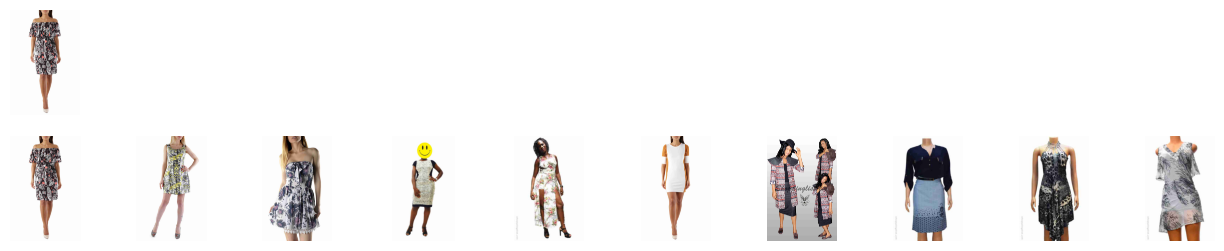

In [14]:
make_recommendations(item_id=7541)

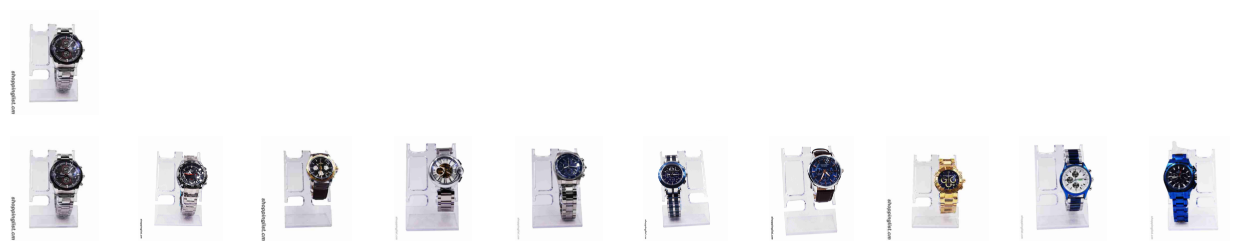

In [15]:
make_recommendations(item_id=6214)

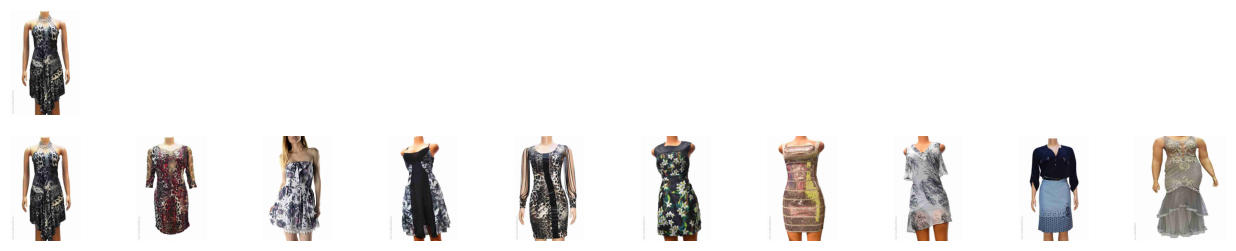

In [16]:
make_recommendations(item_id=5817)

### Example with and without filter

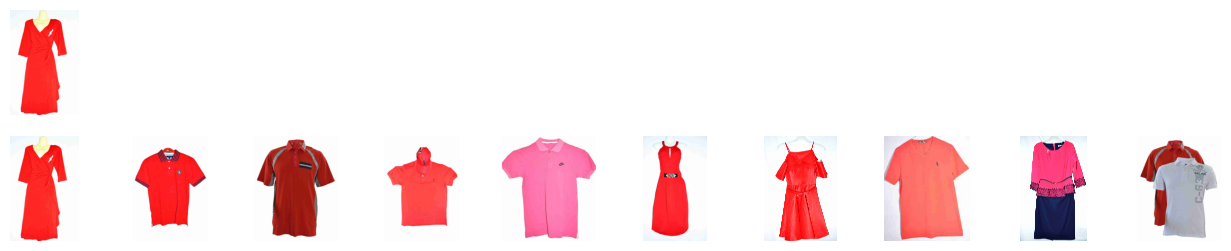

In [17]:
make_recommendations(item_id=1087)

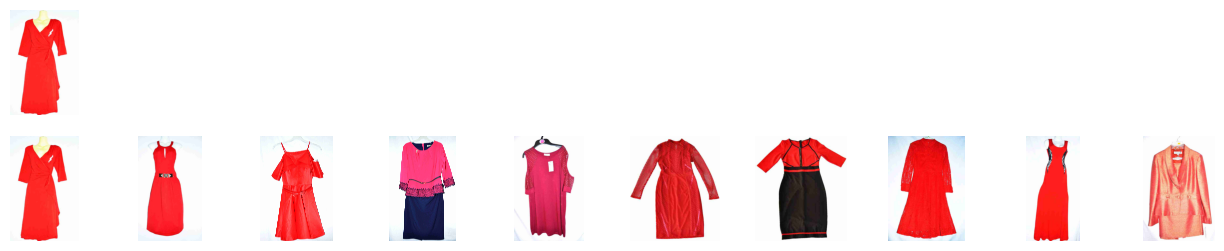

In [18]:
make_recommendations(item_id=1087, apply_filter=True)

In [19]:
import random
def random_item_search():
    # randomly select an item
    random_item_id = random.choice(item_ids)
    print(f"item id: {random_item_id}")

    # run the knn_search for the query item
    item, knns = knn_search(item_id=random_item_id)

    # display the results.
    display_knn(knns, ref_item=item)

item id: 5872


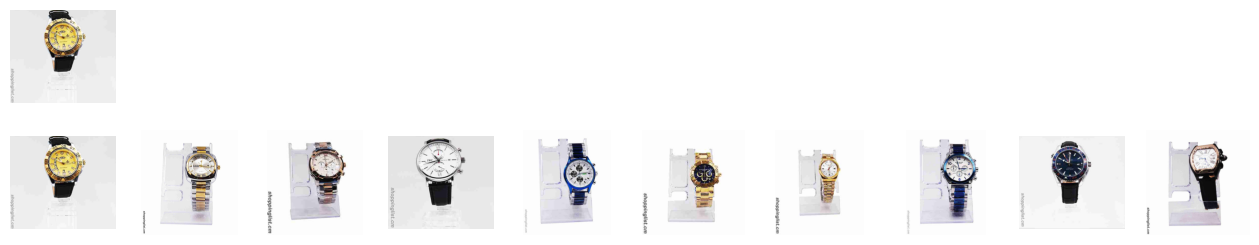

In [20]:
# explore other recommendations
random_item_search()

# Building an Image-based Search Engine

In [21]:
img_paths = [
    os.path.join(DATASET_DIR, 'img1.jpg'), # woman shoes
    os.path.join(DATASET_DIR, 'img2.png')  # woman afritude
]

img_vectors = extract_embeddings_batch(paths=img_paths)

In [22]:
def image_based_search(src_vector, k=10, num_candidates=100):

    # build the knn query.
    knn_query = {
        "knn": {
            "field": "image_features",
            "query_vector": src_vector,
            "k": k,
            "num_candidates": num_candidates
        }
    }
        
    # execute the knn query
    res = es.search(index=index_name, query=knn_query)
    knn_results = res['hits']['hits']
    return knn_results

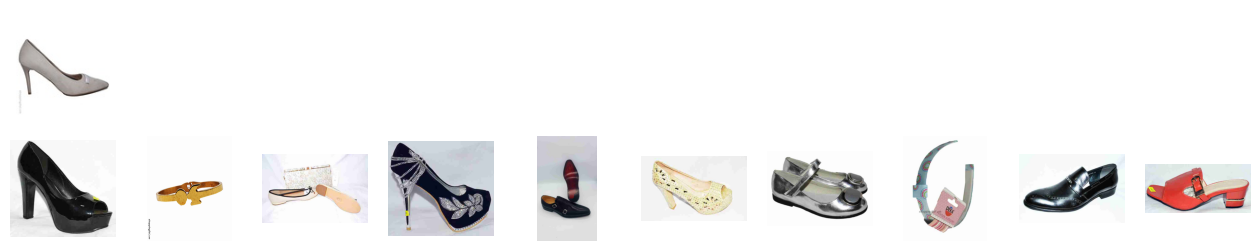

In [23]:
knn_results = image_based_search(img_vectors[0])
display_knn(knn_items=knn_results, src_img_path=img_paths[0])

Second example

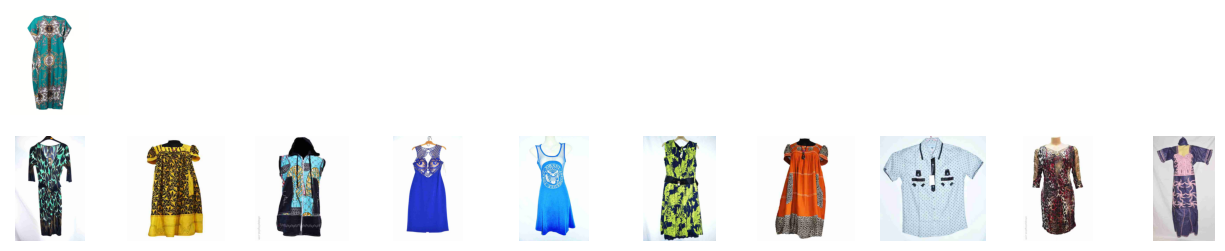

In [24]:
knn2_results = image_based_search(img_vectors[1])
display_knn(knn_items=knn2_results, src_img_path=img_paths[1])

The result is not the great, but as described in [this medium post](https://medium.com/towards-artificial-intelligence/building-an-image-based-recommendation-system-and-search-engine-with-deep-learning-and-4bb96c4d9a64), there is room for improvements.

One way to mitigate this issue is by applying a classification model to determine the category of the item in the image, then applying a filtered knn search using the predicted category.

## Enhancing Image Search Result with Image Classification

Two strategies can be applied for image classification:

* Using classification models: it implies fine-tuning the model to our dataset
* Using multimodal models: using open-source LLM or LLM APIs with well-crafted prompts.

In this notebook, I'm using the Gemini multimodal API for image classification. The steps that should be completed to enhance the search results are the following:

* Extract the list of categories from the metadata.json file,
* Create the classification prompt for Gemini
* Update the search method to classify the input image first, then apply the Elasticsearch filtered knn to get the search result.

### Extract the List of categories from metadata

In [25]:
categories = sorted(list(set(item.get('category')[1] for item in metadata)))

In [27]:
from dotenv import load_dotenv
from google import genai
from google.genai import types
from google.genai import errors

# reset the GEMINI_API_KEY env variable in case it has been changed from the credential file
os.environ.pop('GEMINI_API_KEY', None)

# load env variables from the credential file: it includes the GEMINI_API_KEY env variable
load_dotenv(dotenv_path=os.path.join(PROJECT_DIR, "etc/credentials/.env"))

# initialize the gemini client
client = genai.Client(api_key=os.getenv('GEMINI_API_KEY'))

# Set the classification knowledge base for the gemini api
CLASSIFIER_KB_PATH = os.path.join(SRC_DIR, "classifier kb", "classifier_kb.pdf")
CLASSIFIER_KB_FILE_NAME = "files/ibrs-classifier-kb"

try:
    CLASSIFIER_KB = client.files.upload(
        file=CLASSIFIER_KB_PATH,
        config={
            "name": CLASSIFIER_KB_FILE_NAME,
            "display_name": "IBRS Classifier Knowledge Base",
            "mime_type": "application/pdf"
        }
    )
except errors.ClientError as e:
    if e.code == 409:
        print(f"Knowledge-base {CLASSIFIER_KB_FILE_NAME} already exists. Skipping upload ...")
        CLASSIFIER_KB = client.files.get(name=CLASSIFIER_KB_FILE_NAME)
    else:
        raise e

# set the model to use
MODEL_NAME = "gemini-2.0-flash"

INSTRUCTIONS = """
You are an expert e-commerce item classifier.

The provided knowledge base contains the category definitions and four visual examples in a PDF format.

Study the knowledge base to understand the visual features of each category.

Your Goal is to classify each provided image into exactly one category defined in the knowledge base.
"""

Knowledge-base files/ibrs-classifier-kb already exists. Skipping upload ...


In [28]:
def classify_with_gemini(query_img_path, CLASSIFIER_KB=CLASSIFIER_KB):
    # Load user query image
    with open(query_img_path, "rb") as f:
        query_image_bytes = f.read()

    # Build Prompt
    prompt_parts = [
        # Add the knowledge base as part of the prompt
        CLASSIFIER_KB,

        INSTRUCTIONS,
        
        # Add the new image to classify
        types.Part.from_bytes(data=query_image_bytes, mime_type='image/jpeg'),

        # Task
        "Analyze the above image and assign it to exactly one category defined in the knowledge."
    ]

    # Call Gemini
    response = client.models.generate_content(
        model=MODEL_NAME,
        contents=prompt_parts,
        config=types.GenerateContentConfig(
            response_mime_type="application/json",
            response_schema={
                "type": "object",
                "properties": {
                    "category": {
                        "type": "string",
                        "enum": categories # Force gemini to pick one of the specified category.
                    }
                },
                "required": ["category"]
            }
        )
    )
    
    return response.parsed

In [30]:
print(f"img1 predicted category: {classify_with_gemini(img_paths[0])}")
print(f"img2 predicted category: {classify_with_gemini(img_paths[1])}")

img1 predicted category: {'category': 'Women Shoes'}
img2 predicted category: {'category': 'Fashion Women Afritude'}


Ideally, it would be great/better to use the cached content API. It enables context caching, allowing you to save and reuse precomputed input tokens that you wish to use repeatedly. In this case, using context caching for our image classification task may lead to cost and speed savings, depending on the frequency of the API call for the classification task.

However, the cached content should have at least 4096 tokens, and my classifier_kb file has a total of 323 tokens, which is far from the required minimum total token count. That is why I decided to use the simple file upload API.

### Cached-Content Useful documentation

* https://ai.google.dev/api/caching
* https://googleapis.github.io/python-genai/genai.html#module-genai.caches
* https://googleapis.github.io/python-genai/genai.html#genai.types.CreateCachedContentConfig

In [31]:
def enhanced_image_based_search(src_img, k=10, num_candidates=100):
    
    # Use Gemini to get the category of the image
    predicted_category = classify_with_gemini(src_img)

    # extract embeddings of the source image
    src_vector = extract_embeddings_batch(paths=[src_img])

    # build the knn query.
    knn_query = {
        "knn": {
            "field": "image_features",
            "query_vector": src_vector[0],
            "k": k,
            "num_candidates": num_candidates,
            "filter": {
                "term": {
                    "category": predicted_category['category']
                }
            }
        }
    }
        
    # execute the knn query
    res = es.search(index=index_name, query=knn_query)
    knn_results = res['hits']['hits']
    return knn_results

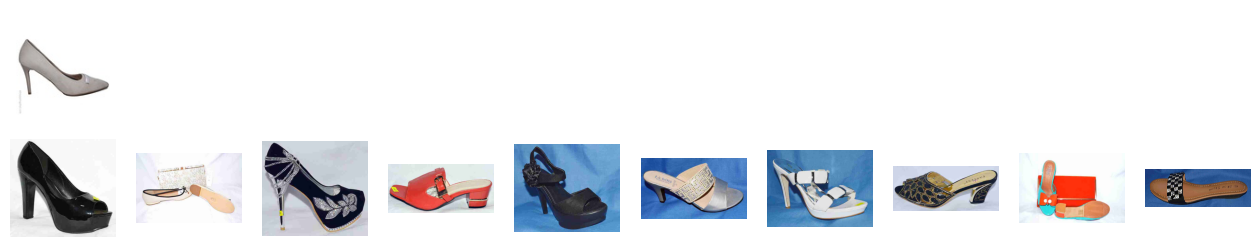

In [32]:
knn_results = enhanced_image_based_search(img_paths[0])
display_knn(knn_items=knn_results, src_img_path=img_paths[0])

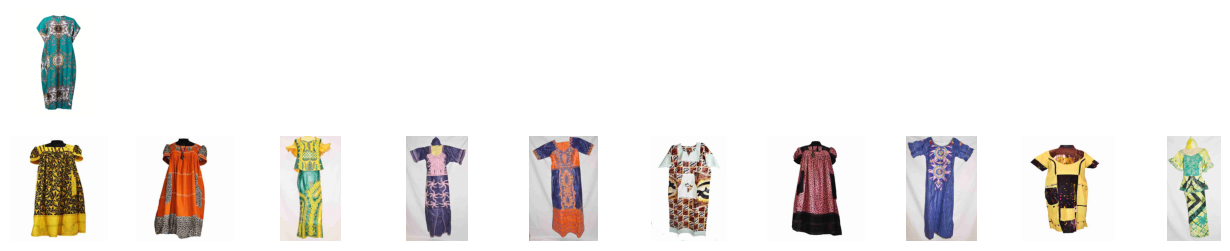

In [33]:
knn_results = enhanced_image_based_search(img_paths[1])
display_knn(knn_items=knn_results, src_img_path=img_paths[1])

The resulting recommendations are much better than the previous ones, as all the recommended items now belong to the predicted category.

### Author
Carmel WENGA, Data & ML Engineer
- [Medium](https://medium.com/@carmelwenga)
- [LinkedIn](https://www.linkedin.com/in/carmel-christian-wenga-871876178/)